<a href="https://colab.research.google.com/github/astridcvr/daily-ml-practice/blob/main/day_21_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading datasets from GitHub...

Shapes:
X_train_num: (2258, 8)  X_test_num: (565, 8)

Running Elbow Method...


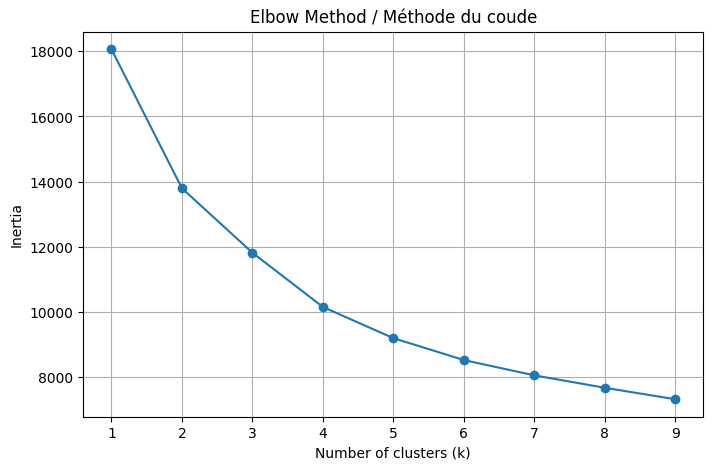


Training final KMeans model with k=3...
Clustering completed.

Cluster Summary:


,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,QTR_ID,MONTH_ID,YEAR_ID,MSRP
cluster,,,,,,,,
0,10185.810458,34.807190,83.861225,6.148693,1.593137,3.689542,2003.581699,101.194444
1,10254.226877,34.725692,83.649526,6.807905,3.696443,10.038735,2003.573123,101.093281
2,10391.635171,36.716535,83.240394,6.070866,1.356955,2.950131,2005.000000,99.194226



Cluster summary saved locally: day_21_clusters_summary.csv
          ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    QTR_ID  \
cluster                                                                        
0        10185.810458        34.807190  83.861225         6.148693  1.593137   
1        10254.226877        34.725692  83.649526         6.807905  3.696443   
2        10391.635171        36.716535  83.240394         6.070866  1.356955   

          MONTH_ID      YEAR_ID        MSRP  
cluster                                      
0         3.689542  2003.581699  101.194444  
1        10.038735  2003.573123  101.093281  
2         2.950131  2005.000000   99.194226  


In [2]:
# ============================================================
# Day 21 - Clustering / Segmentation
# KMeans Clustering on Numeric Variables
#
# Author: Astrid Villalobos
# ============================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------
# Load datasets
# -------------------------------------------
print("Loading datasets from GitHub...\n")

train_url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_train.csv"
test_url = "https://raw.githubusercontent.com/astridcvr/daily-ml-practice/main/data/X_test.csv"

X_train = pd.read_csv(train_url)
X_test = pd.read_csv(test_url)

# Keep only numeric columns
X_train_num = X_train.select_dtypes(include=[np.number])
X_test_num = X_test.select_dtypes(include=[np.number])

print("Shapes:")
print(f"X_train_num: {X_train_num.shape}  X_test_num: {X_test_num.shape}")

# -------------------------------------------
# Scaling for clustering
# -------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_num)

# -------------------------------------------
# Elbow Method
# -------------------------------------------
print("\nRunning Elbow Method...")

inertia_scores = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_scores, marker='o')
plt.title("Elbow Method / Méthode du coude")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

# -------------------------------------------
# Fit final model
# -------------------------------------------
k_final = 3
print(f"\nTraining final KMeans model with k={k_final}...")

kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("Clustering completed.")

# -------------------------------------------
# Analyze clusters
# -------------------------------------------
clustered_df = X_train_num.copy()
clustered_df["cluster"] = clusters

cluster_summary = clustered_df.groupby("cluster").mean()

print("\nCluster Summary:")
display(cluster_summary)

# -------------------------------------------
# Save results
# -------------------------------------------
save_path = "day_21_clusters_summary.csv"
cluster_summary.to_csv(save_path, index=True)

print(f"\nCluster summary saved locally: {save_path}")
print(cluster_summary)

